In [10]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# Load data
train = pd.read_csv("../data/processed/train.csv")
val = pd.read_csv("../data/processed/validation.csv")
test = pd.read_csv("../data/processed/test.csv")

print("Train:", train.shape)

Train: (80000, 4)


In [11]:
print(train.columns)

Index(['user_id', 'item_id', 'rating', 'timestamp'], dtype='object')


In [12]:
user_activity = train.groupby("user_id").size()

In [13]:
k = 10  # smoothing parameter (you will tune this later)

def compute_adaptive_weights(user):
    # Handle unseen users safely
    activity = user_activity.get(user, 0)

    # More active user → higher alpha (trust bias/more stable model)
    alpha_u = activity / (activity + k)

    # Remaining weight split between KNN models
    remaining = 1 - alpha_u

    beta_u = remaining * 0.5       # userKNN weight
    gamma_u = remaining * 0.5      # itemKNN weight

    return alpha_u, beta_u, gamma_u

In [14]:
print(user_activity.head())
print(compute_adaptive_weights(user_activity.index[0]))

user_id
1    207
2     42
3     44
4     20
5    147
dtype: int64
(np.float64(0.9539170506912442), np.float64(0.02304147465437789), np.float64(0.02304147465437789))


In [15]:
from hybrid import HybridRecommender

In [16]:
# ---- Train Bias Model ----
from baseline import BiasModel

bias_model = BiasModel()
bias_model.fit(train)


# ---- Train UserKNN ----
from knn import UserKNN

user_knn_model = UserKNN(k=20)
user_knn_model.fit(train)


# ---- Train ItemKNN ----
from knn import ItemKNN

item_knn_model = ItemKNN(k=40)
item_knn_model.fit(train)

In [17]:
hybrid_model = HybridRecommender(
    bias_model=bias_model,
    user_knn_model=user_knn_model,
    item_knn_model=item_knn_model,
    alpha=0.3,
    beta=0.4
)

val_preds_hybrid = hybrid_model.predict(val)

rmse_hybrid = np.sqrt(mean_squared_error(val["rating"], val_preds_hybrid))

print("Validation RMSE (Hybrid):", round(rmse_hybrid, 4))

Validation RMSE (Hybrid): 0.9325


In [18]:
# --- Adaptive Hybrid (VALIDATION) ---

# Get predictions from individual models
bias_preds_val = bias_model.predict(val)
user_preds_val = user_knn_model.predict(val)
item_preds_val = item_knn_model.predict(val)

adaptive_preds = []

for i in range(len(val)):
    user = val.iloc[i]["user_id"]

    alpha_u, beta_u, gamma_u = compute_adaptive_weights(user)

    pred = (
        alpha_u * bias_preds_val[i] +
        beta_u * user_preds_val[i] +
        gamma_u * item_preds_val[i]
    )

    adaptive_preds.append(pred)

rmse_adaptive = np.sqrt(mean_squared_error(val["rating"], adaptive_preds))

print("Validation RMSE (Adaptive Hybrid):", round(rmse_adaptive, 4))

Validation RMSE (Adaptive Hybrid): 0.9674


In [22]:
best_rmse = float("inf")
best_params = None

for alpha in np.arange(0.1, 0.6, 0.1):
    for beta in np.arange(0.1, 0.6, 0.1):

        if alpha + beta >= 1:
            continue

        model = HybridRecommender(
            bias_model=bias_model,
            user_knn_model=user_knn_model,
            item_knn_model=item_knn_model,
            alpha=alpha,
            beta=beta
        )

        preds = model.predict(val)
        rmse = np.sqrt(mean_squared_error(val["rating"], preds))

        print(f"alpha={alpha:.1f}, beta={beta:.1f}, RMSE={rmse:.4f}")

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = (alpha, beta)

print("\nBest parameters:", best_params)
print("Best RMSE:", round(best_rmse, 4))

alpha=0.1, beta=0.1, RMSE=0.9563
alpha=0.1, beta=0.2, RMSE=0.9458
alpha=0.1, beta=0.3, RMSE=0.9377
alpha=0.1, beta=0.4, RMSE=0.9321
alpha=0.1, beta=0.5, RMSE=0.9290
alpha=0.2, beta=0.1, RMSE=0.9485
alpha=0.2, beta=0.2, RMSE=0.9402
alpha=0.2, beta=0.3, RMSE=0.9343
alpha=0.2, beta=0.4, RMSE=0.9309
alpha=0.2, beta=0.5, RMSE=0.9301
alpha=0.3, beta=0.1, RMSE=0.9433
alpha=0.3, beta=0.2, RMSE=0.9372
alpha=0.3, beta=0.3, RMSE=0.9336
alpha=0.3, beta=0.4, RMSE=0.9325
alpha=0.3, beta=0.5, RMSE=0.9340
alpha=0.4, beta=0.1, RMSE=0.9409
alpha=0.4, beta=0.2, RMSE=0.9370
alpha=0.4, beta=0.3, RMSE=0.9357
alpha=0.4, beta=0.4, RMSE=0.9369
alpha=0.4, beta=0.5, RMSE=0.9406
alpha=0.5, beta=0.1, RMSE=0.9412
alpha=0.5, beta=0.2, RMSE=0.9396
alpha=0.5, beta=0.3, RMSE=0.9405
alpha=0.5, beta=0.4, RMSE=0.9440

Best parameters: (np.float64(0.1), np.float64(0.5))
Best RMSE: 0.929


In [23]:
best_alpha, best_beta = best_params

final_hybrid = HybridRecommender(
    bias_model=bias_model,
    user_knn_model=user_knn_model,
    item_knn_model=item_knn_model,
    alpha=best_alpha,
    beta=best_beta
)

test_preds = final_hybrid.predict(test)
test_rmse = np.sqrt(mean_squared_error(test["rating"], test_preds))

print("Final Test RMSE (Hybrid):", round(test_rmse, 4))

Final Test RMSE (Hybrid): 0.9291


In [24]:
# --- Adaptive Hybrid (TEST) ---

bias_preds_test = bias_model.predict(test)
user_preds_test = user_knn_model.predict(test)
item_preds_test = item_knn_model.predict(test)

adaptive_test_preds = []

for i in range(len(test)):
    user = test.iloc[i]["user_id"]

    alpha_u, beta_u, gamma_u = compute_adaptive_weights(user)

    pred = (
        alpha_u * bias_preds_test[i] +
        beta_u * user_preds_test[i] +
        gamma_u * item_preds_test[i]
    )

    adaptive_test_preds.append(pred)

test_rmse_adaptive = np.sqrt(mean_squared_error(test["rating"], adaptive_test_preds))

print("Test RMSE (Adaptive Hybrid):", round(test_rmse_adaptive, 4))

Test RMSE (Adaptive Hybrid): 0.9617


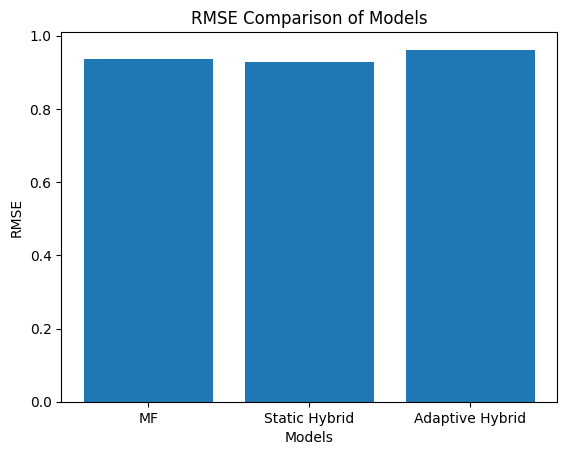

In [25]:
import matplotlib.pyplot as plt

models = ['MF', 'Static Hybrid', 'Adaptive Hybrid']
rmse = [0.9361, test_rmse, test_rmse_adaptive]

plt.figure()
plt.bar(models, rmse)
plt.xlabel('Models')
plt.ylabel('RMSE')
plt.title('RMSE Comparison of Models')

plt.savefig("../results/figures/rmse_comparison.png")
plt.show()

In [32]:
def recommend_top_n(user, n=5):
    items = test["item_id"].unique()   # already fixed
    
    preds = []

    # Get all predictions once (efficient)
    user_df = pd.DataFrame({
        "user_id": [user] * len(items),
        "item_id": items
    })

    bias_preds = bias_model.predict(user_df)
    user_preds = user_knn_model.predict(user_df)
    item_preds = item_knn_model.predict(user_df)

    for i in range(len(items)):
        alpha, beta, gamma = compute_adaptive_weights(user)

        pred = (
                alpha * bias_preds[i] +
                beta * user_preds[i] +
                gamma * item_preds[i]
            )

        # Clip to rating scale
        pred = min(5, max(1, pred))

        preds.append((items[i], pred + np.random.uniform(0, 0.01)))

    preds.sort(key=lambda x: x[1], reverse=True)

    return preds[:n]
print(recommend_top_n(user=1))

[(np.int64(1612), 5.009912957188734), (np.int64(1467), 5.009125674433101), (np.int64(1189), 5.008365860038516), (np.int64(1306), 5.001825912467826), (np.int64(1629), 5.000089783861422)]
